# Plantilla EDA + Modelo base — Datathon MedData Challenge

**Uso rápido:** cambia solo la celda de CONFIGURACION (ruta del CSV y nombre de la
variable objetivo) y ejecuta todo con `Kernel > Restart & Run All`.

Orden: cargar -> explorar -> limpiar -> modelar -> reportar -> **Hallazgos**.

> Recuerda: el objetivo es **terminar**, no optimizar.


In [1]:
# === 0. IMPORTS Y AJUSTES GLOBALES ==========================================
import warnings
warnings.filterwarnings("ignore")   # silencia avisos que solo estorban en vivo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)

# Que pandas no recorte columnas al imprimir (clave para leer .describe())
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")     # estetica decente sin esfuerzo
plt.rcParams["figure.figsize"] = (10, 5)

print("Librerias cargadas | pandas", pd.__version__, "| sklearn OK")

Librerias cargadas | pandas 2.3.3 | sklearn OK


## 1. Configuración — *lo único que normalmente tienes que tocar*

In [1]:
# === 1. CONFIGURACION ======================================================
from pathlib import Path

# Ruta del CSV como VARIABLE: cambiala y el resto del notebook sigue funcionando.
RUTA_CSV = Path("../data/diabetes_012_heart_disease.csv")

# Nombre EXACTO de la columna objetivo (lo que quieres predecir).
#   pima_diabetes.csv    -> "Outcome"
#   heart_disease.csv    -> "num"     (0 = sano, 1-4 = enfermo -> ver celda 6)
#   stroke_prediction.csv-> "stroke"
TARGET = "num"

# Columnas a descartar de una (IDs, folios, cosas sin valor predictivo).
COLS_A_ELIMINAR = []          # ej. ["id"] en el dataset de stroke

# Carpeta donde guardar graficas / entregables.
OUT = Path("../outputs"); OUT.mkdir(exist_ok=True)

SEMILLA = 42                  # reproducibilidad: siempre la misma particion
print("CSV:", RUTA_CSV.resolve(), "| existe:", RUTA_CSV.exists())

CSV: /Users/cornelio/Desktop/UTP/2026/Concursos/Medata/datathon-meddata/data/diabetes_012_heart_disease.csv | existe: False


## 2. Cargar los datos

In [2]:
# === 2. CARGA ==============================================================
df = pd.read_csv(RUTA_CSV)

# Si el CSV viene raro, prueba estos argumentos en vez de la linea de arriba:
# df = pd.read_csv(RUTA_CSV, sep=";")                      # separador punto y coma
# df = pd.read_csv(RUTA_CSV, encoding="latin-1")           # acentos rotos / UnicodeDecodeError
# df = pd.read_csv(RUTA_CSV, na_values=["?", "NA", "", "N/A", "-"])  # nulos disfrazados
# df = pd.read_excel(RUTA_CSV, sheet_name=0)               # si es .xlsx (usa openpyxl)

df_original = df.copy()       # copia de seguridad: si arruinas df, vuelves aqui
print("Filas x columnas:", df.shape)
df.head()

NameError: name 'pd' is not defined

## 3. Radiografía rápida: `shape` / `info()` / `describe()`

In [4]:
# === 3. EXPLORACION BASICA =================================================
print("SHAPE (filas, columnas):", df.shape, "\n")

print("--- INFO: tipos y no-nulos por columna ---")
df.info()

print("\n--- DESCRIBE: estadisticos de las columnas numericas ---")
display(df.describe().T)     # .T = transpuesta, se lee mucho mejor

# Si hay columnas de texto/categoricas, tambien describelas:
if df.select_dtypes(include="object").shape[1] > 0:
    print("\n--- DESCRIBE de columnas categoricas ---")
    display(df.describe(include="object").T)

SHAPE (filas, columnas): (303, 14) 

--- INFO: tipos y no-nulos por columna ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB

--- DESCRIBE: estadisticos de las columnas numericas ---


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 4. Nulos, duplicados y tipos de datos

In [5]:
# === 4a. NULOS =============================================================
nulos = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
})
nulos = nulos[nulos.n_nulos > 0].sort_values("n_nulos", ascending=False)

if nulos.empty:
    print("Sin valores nulos declarados (NaN).")
else:
    display(nulos)

# OJO en datos de salud: los nulos se disfrazan de CEROS imposibles.
# (glucosa=0, presion=0, IMC=0 no existen en un paciente vivo)
sospechosas = [c for c in df.select_dtypes(include=np.number).columns
               if c != TARGET and (df[c] == 0).sum() > 0]
if sospechosas:
    print("\nColumnas numericas con ceros (revisa si son nulos disfrazados):")
    display((df[sospechosas] == 0).sum().sort_values(ascending=False).to_frame("n_ceros"))

,n_nulos,pct_nulos
ca,4,1.32
thal,2,0.66



Columnas numericas con ceros (revisa si son nulos disfrazados):


,n_ceros
fbs,258
exang,204
ca,176
restecg,151
oldpeak,99
sex,97


In [6]:
# === 4b. DUPLICADOS ========================================================
n_dup = df.duplicated().sum()
print(f"Filas duplicadas completas: {n_dup}  ({n_dup/len(df)*100:.2f}%)")

if n_dup:
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))
    # df = df.drop_duplicates().reset_index(drop=True)   # <- descomenta para eliminarlos
    # print("Nuevo shape:", df.shape)

Filas duplicadas completas: 0  (0.00%)


In [7]:
# === 4c. TIPOS DE DATOS ====================================================
tipos = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "n_unicos": df.nunique(),
    "ejemplo": df.iloc[0],
})
display(tipos)

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("Numericas :", num_cols)
print("Categoricas:", cat_cols)

# Trampa clasica: una columna numerica leida como texto por un separador raro.
# df["col"] = pd.to_numeric(df["col"], errors="coerce")   # lo que no convierta -> NaN

,tipo,n_unicos,ejemplo
age,int64,41,63.0
sex,int64,2,1.0
cp,int64,4,1.0
trestbps,int64,50,145.0
chol,int64,152,233.0
fbs,int64,2,1.0
restecg,int64,3,2.0
thalach,int64,91,150.0
exang,int64,2,0.0
oldpeak,float64,40,2.3


Numericas : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
Categoricas: []


## 5. Gráficas rápidas

Cuatro vistas que casi siempre dicen algo: distribución, outliers, balance de
clases y correlaciones. Todas se guardan en `outputs/`.

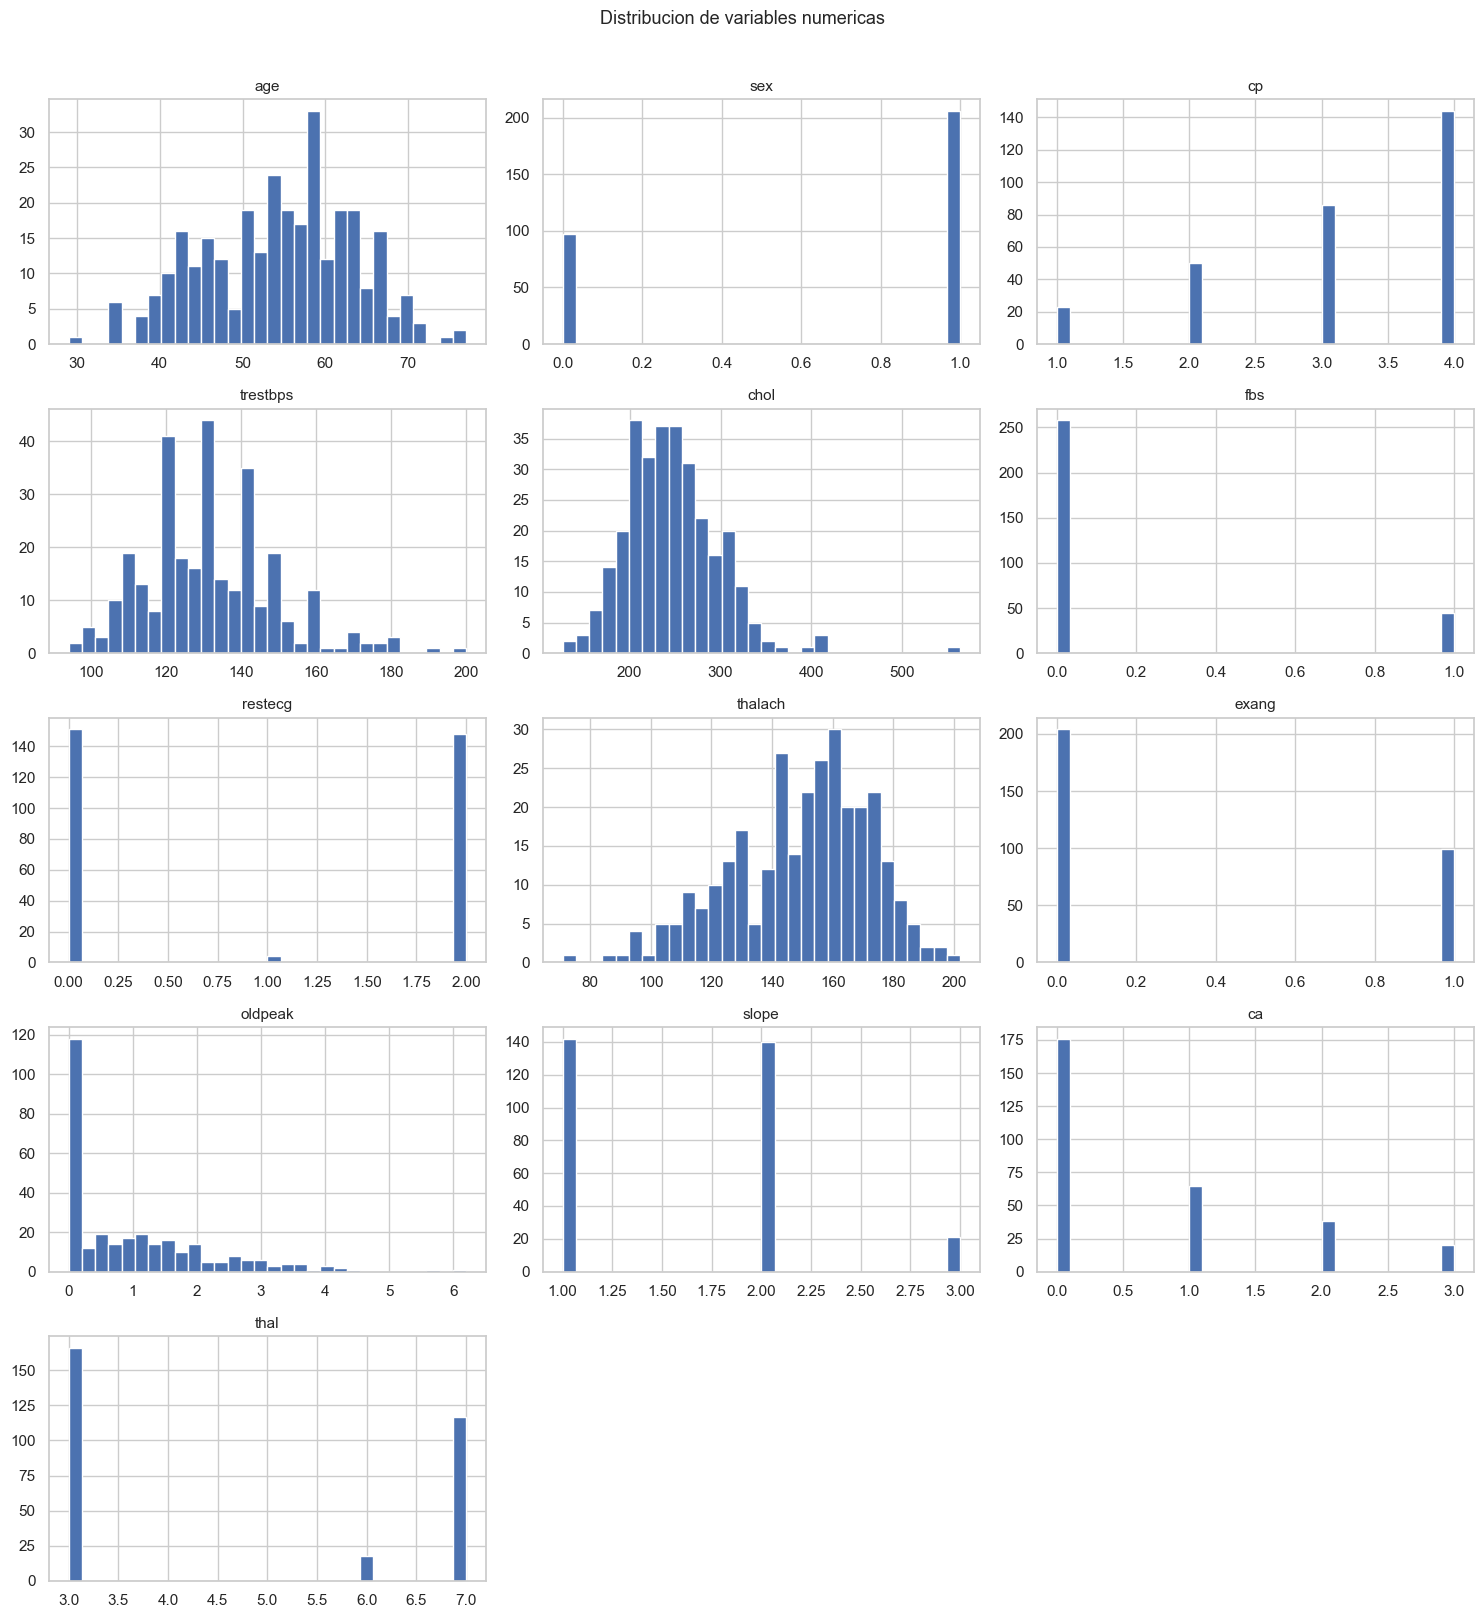

In [8]:
# === 5a. HISTOGRAMAS de todas las numericas ================================
cols_hist = [c for c in num_cols if c != TARGET]
n = len(cols_hist)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows))
axes = np.array(axes).ravel()
for ax, col in zip(axes, cols_hist):
    df[col].hist(bins=30, ax=ax, edgecolor="white")
    ax.set_title(col, fontsize=11)
for ax in axes[n:]:
    ax.set_visible(False)          # apaga los subplots sobrantes
fig.suptitle("Distribucion de variables numericas", y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(OUT / "01_histogramas.png", dpi=110, bbox_inches="tight")
plt.show()

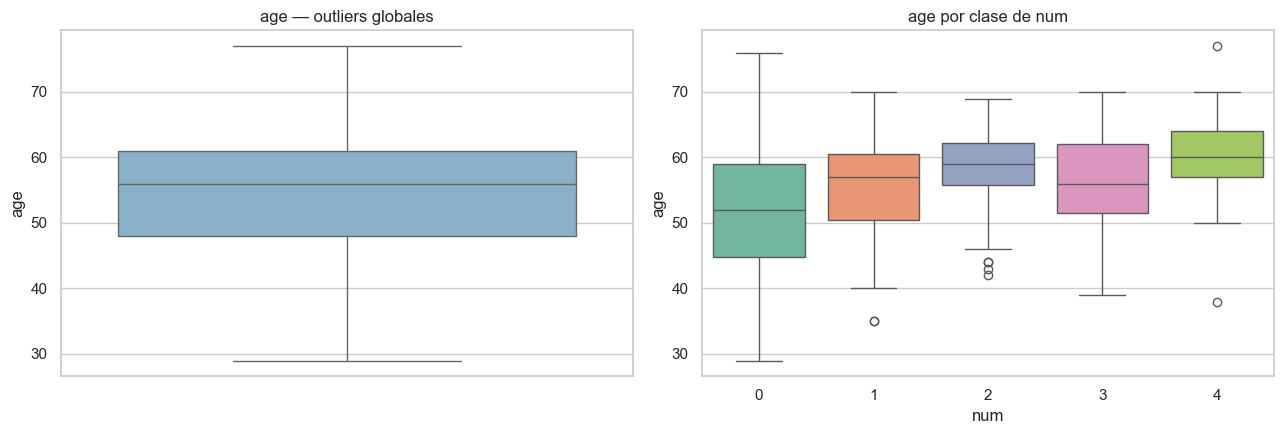

In [14]:
# === 5b. BOXPLOT: outliers + relacion con el target ========================
# Elige la variable que mas te interese; por defecto, la primera numerica.
VAR_BOX = cols_hist[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(y=df[VAR_BOX], ax=axes[0], color="#7fb3d5")
axes[0].set_title(f"{VAR_BOX} — outliers globales")

sns.boxplot(data=df, x=TARGET, y=VAR_BOX, ax=axes[1], palette="Set2")
axes[1].set_title(f"{VAR_BOX} por clase de {TARGET}")

fig.tight_layout()
fig.savefig(OUT / "02_boxplot.png", dpi=110, bbox_inches="tight")
plt.show()

# Vista compacta de TODAS las numericas a la vez (escala normalizada):
# df[cols_hist].apply(lambda s: (s - s.mean()) / s.std()).boxplot(figsize=(12,4), rot=45);

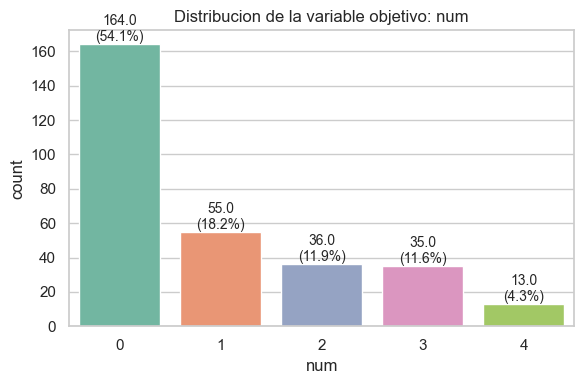

num
0    54.13
1    18.15
2    11.88
3    11.55
4     4.29
Name: proportion, dtype: float64


In [15]:
# === 5c. COUNTPLOT del target: ¿estan balanceadas las clases? ==============
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x=TARGET, palette="Set2", ax=ax)
ax.set_title(f"Distribucion de la variable objetivo: {TARGET}")

# Etiqueta cada barra con su porcentaje (esto es lo que el jurado quiere ver)
total = len(df)
for p in ax.patches:
    ax.annotate(f"{p.get_height()}\n({p.get_height()/total*100:.1f}%)",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

fig.tight_layout()
fig.savefig(OUT / "03_balance_target.png", dpi=110, bbox_inches="tight")
plt.show()

print(df[TARGET].value_counts(normalize=True).round(4) * 100)
# Si una clase es <20%, el accuracy MIENTE. Mira recall/f1 y usa class_weight="balanced".

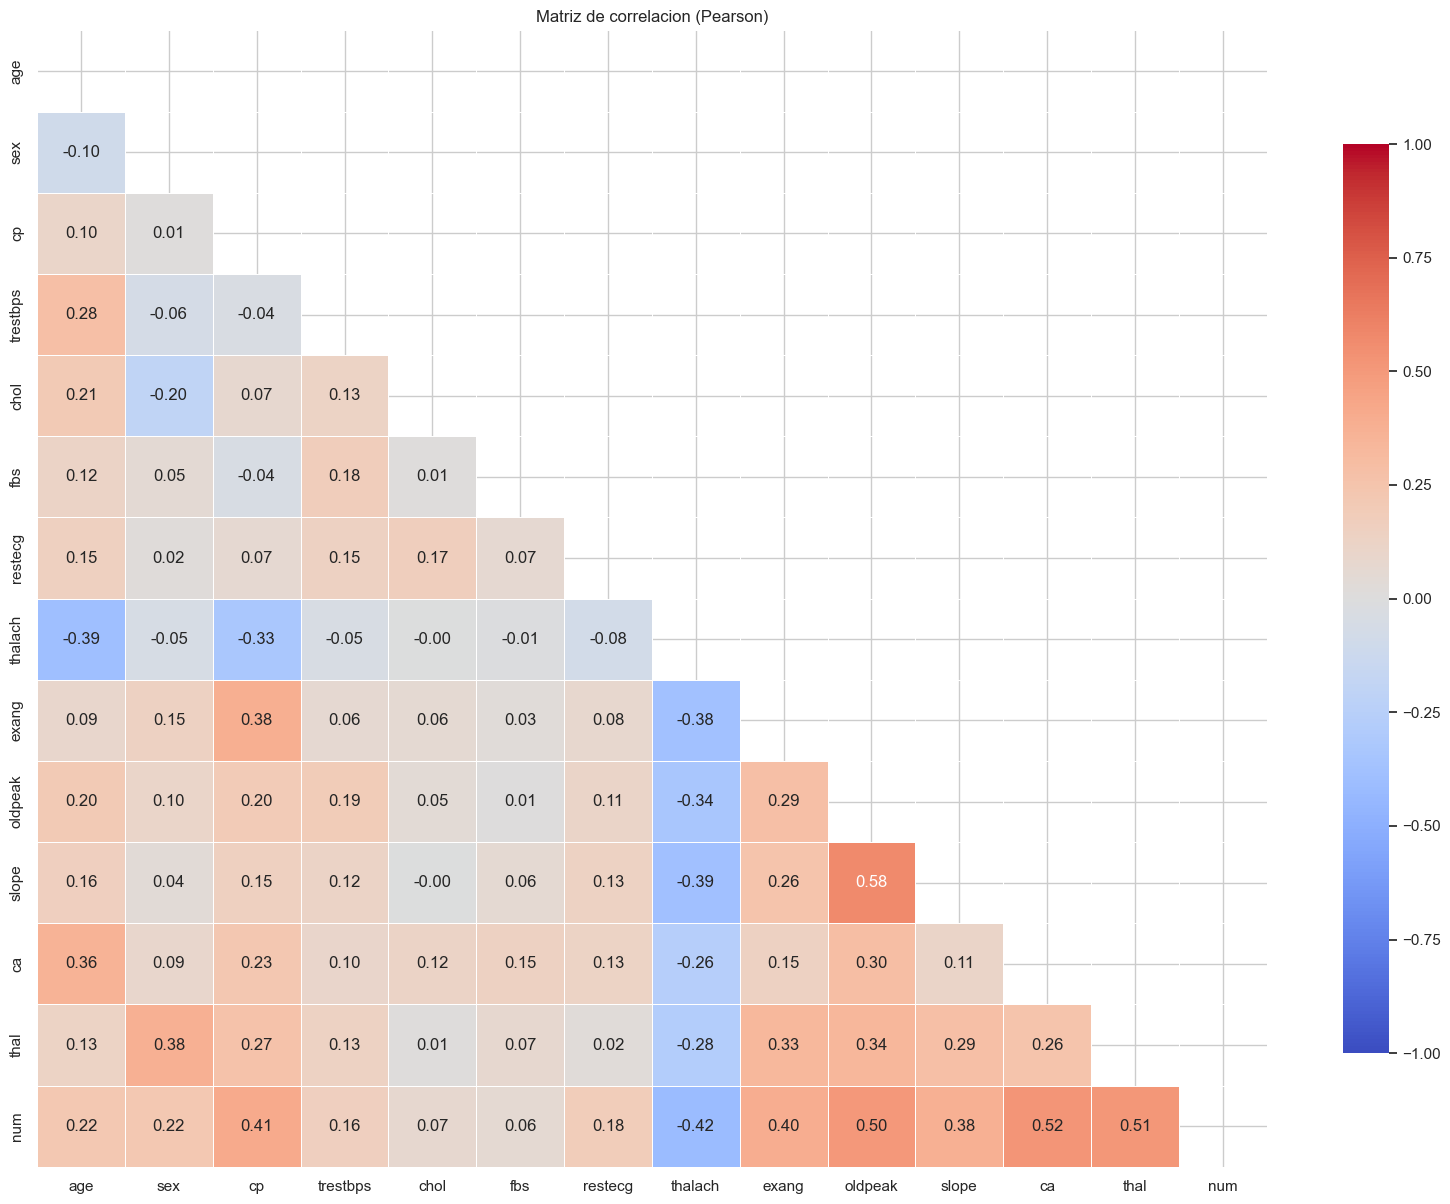


Correlacion con num (ordenada por magnitud):
ca          0.519
thal        0.510
oldpeak     0.504
thalach    -0.415
cp          0.407
exang       0.397
slope       0.378
sex         0.224
age         0.223
restecg     0.184
trestbps    0.158
chol        0.071
fbs         0.059
Name: num, dtype: float64


In [16]:
# === 5d. HEATMAP de correlaciones ==========================================
corr = df[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(1.0*len(num_cols)+2, 0.8*len(num_cols)+1))
mask = np.triu(np.ones_like(corr, dtype=bool))    # oculta el triangulo superior
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=False, linewidths=.5,
            cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Matriz de correlacion (Pearson)")
fig.tight_layout()
fig.savefig(OUT / "04_heatmap_correlacion.png", dpi=110, bbox_inches="tight")
plt.show()

# Lo que de verdad importa: que correlaciona con el target
if TARGET in corr.columns:
    print("\nCorrelacion con", TARGET, "(ordenada por magnitud):")
    print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3))

## 6. Limpieza y preparación

Bloques comentados: **descomenta solo lo que tu dataset necesite**.

In [17]:
# === 6a. LIMPIEZA: nulos, tipos, fechas ====================================
# Trabajamos sobre una copia para poder volver atras sin re-cargar el CSV.
dfc = df.copy()

# --- Eliminar columnas inutiles (IDs, folios) ---
if COLS_A_ELIMINAR:
    dfc = dfc.drop(columns=[c for c in COLS_A_ELIMINAR if c in dfc.columns])

# --- Ceros imposibles -> NaN (tipico en datos clinicos) ---
# CEROS_IMPOSIBLES = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
# dfc[CEROS_IMPOSIBLES] = dfc[CEROS_IMPOSIBLES].replace(0, np.nan)

# --- FILLNA: numericas con mediana (robusta a outliers), categoricas con moda ---
for col in dfc.select_dtypes(include=np.number).columns:
    if dfc[col].isna().any():
        dfc[col] = dfc[col].fillna(dfc[col].median())
        print(f"fillna mediana -> {col}")

for col in dfc.select_dtypes(include="object").columns:
    if dfc[col].isna().any():
        dfc[col] = dfc[col].fillna(dfc[col].mode()[0])
        print(f"fillna moda    -> {col}")

# Otras opciones: .fillna(0) | .fillna(method="ffill") | .dropna(subset=["col"])

# --- ASTYPE: forzar tipos ---
# dfc["edad"]  = dfc["edad"].astype(int)
# dfc["clase"] = dfc["clase"].astype("category")
# dfc[TARGET]  = dfc[TARGET].astype(int)

# --- PD.TO_DATETIME: fechas + variables derivadas ---
COLS_FECHA = []      # ej. ["fecha_ingreso", "fecha_alta"]
for col in COLS_FECHA:
    dfc[col] = pd.to_datetime(dfc[col], errors="coerce")   # dayfirst=True si es DD/MM/AAAA
    dfc[col + "_anio"] = dfc[col].dt.year
    dfc[col + "_mes"]  = dfc[col].dt.month
# Diferencia entre dos fechas en dias:
# dfc["dias_estancia"] = (dfc["fecha_alta"] - dfc["fecha_ingreso"]).dt.days

print("\nShape tras limpieza:", dfc.shape, "| nulos restantes:", int(dfc.isna().sum().sum()))

fillna mediana -> ca
fillna mediana -> thal

Shape tras limpieza: (303, 14) | nulos restantes: 0


In [18]:
# === 6b. ENCODING: get_dummies para las categoricas ========================
cat_restantes = dfc.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categoricas a codificar:", cat_restantes)

dfc = pd.get_dummies(dfc, columns=cat_restantes, drop_first=True, dtype=int)
# drop_first=True evita la colinealidad (n categorias -> n-1 columnas)
# dummy_na=True  si quieres que "faltante" sea una categoria mas

print("Shape tras get_dummies:", dfc.shape)
dfc.head(3)

Categoricas a codificar: []
Shape tras get_dummies: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1


In [19]:
# === 6c. TARGET BINARIO ====================================================
# Muchos datasets clinicos traen la severidad en escala (0,1,2,3,4).
# Para un modelo base, binariza: 0 = sano, 1 = enfermo.
print("Valores del target:", sorted(dfc[TARGET].unique()))

if dfc[TARGET].nunique() > 2:
    dfc[TARGET] = (dfc[TARGET] > 0).astype(int)
    print("-> Binarizado a 0/1:", dfc[TARGET].value_counts().to_dict())

Valores del target: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
-> Binarizado a 0/1: {0: 164, 1: 139}


## 7. `train_test_split`

In [21]:
# === 7. SEPARAR X / y Y PARTIR EN TRAIN/TEST ===============================
X = dfc.drop(columns=[TARGET])
y = dfc[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEMILLA,
    stratify=y,          # CLAVE con clases desbalanceadas: mantiene la proporcion
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Proporcion de clase 1 -> train:", round(y_train.mean(), 3),
      "| test:", round(y_test.mean(), 3))

# Escalado: obligatorio para LogisticRegression, indiferente para RandomForest.
# Se ajusta SOLO con train (fit_transform) y se aplica a test (transform).
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train: (242, 13) | X_test: (61, 13)
Proporcion de clase 1 -> train: 0.459 | test: 0.459


## 8. Modelos base: Regresión Logística y Random Forest

In [22]:
# === 8a. MODELO 1: REGRESION LOGISTICA =====================================
# Rapido, interpretable (coeficientes = direccion del efecto). Necesita escalado.
logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # compensa el desbalance de clases
    random_state=SEMILLA,
)
logreg.fit(X_train_sc, y_train)

pred_lr  = logreg.predict(X_test_sc)
proba_lr = logreg.predict_proba(X_test_sc)[:, 1]
print("LogisticRegression | accuracy:", round(logreg.score(X_test_sc, y_test), 4),
      "| ROC-AUC:", round(roc_auc_score(y_test, proba_lr), 4))

LogisticRegression | accuracy: 0.8689 | ROC-AUC: 0.9502


In [23]:
# === 8b. MODELO 2: RANDOM FOREST ===========================================
# Capta relaciones no lineales, da importancia de variables, no requiere escalado.
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=SEMILLA,
    n_jobs=-1,
)
rf.fit(X_train, y_train)          # sin escalar, a proposito

pred_rf  = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]
print("RandomForest       | accuracy:", round(rf.score(X_test, y_test), 4),
      "| ROC-AUC:", round(roc_auc_score(y_test, proba_rf), 4))

RandomForest       | accuracy: 0.918 | ROC-AUC: 0.9594


## 9. Evaluación: `classification_report` + matriz de confusión

In [24]:
# === 9a. CLASSIFICATION REPORT =============================================
for nombre, y_pred in [("LOGISTIC REGRESSION", pred_lr), ("RANDOM FOREST", pred_rf)]:
    print("=" * 62)
    print(nombre)
    print("=" * 62)
    print(classification_report(y_test, y_pred, digits=3,
                                target_names=["negativo (0)", "positivo (1)"]))

# Como leerlo en salud:
#   RECALL de la clase 1 = de todos los enfermos reales, cuantos detecte.
#                          Es la metrica que importa: un falso negativo es un
#                          paciente que se va a casa enfermo.
#   PRECISION de la clase 1 = de los que marque como enfermos, cuantos lo eran.

LOGISTIC REGRESSION
              precision    recall  f1-score   support

negativo (0)      0.931     0.818     0.871        33
positivo (1)      0.812     0.929     0.867        28

    accuracy                          0.869        61
   macro avg      0.872     0.873     0.869        61
weighted avg      0.877     0.869     0.869        61

RANDOM FOREST
              precision    recall  f1-score   support

negativo (0)      0.967     0.879     0.921        33
positivo (1)      0.871     0.964     0.915        28

    accuracy                          0.918        61
   macro avg      0.919     0.922     0.918        61
weighted avg      0.923     0.918     0.918        61



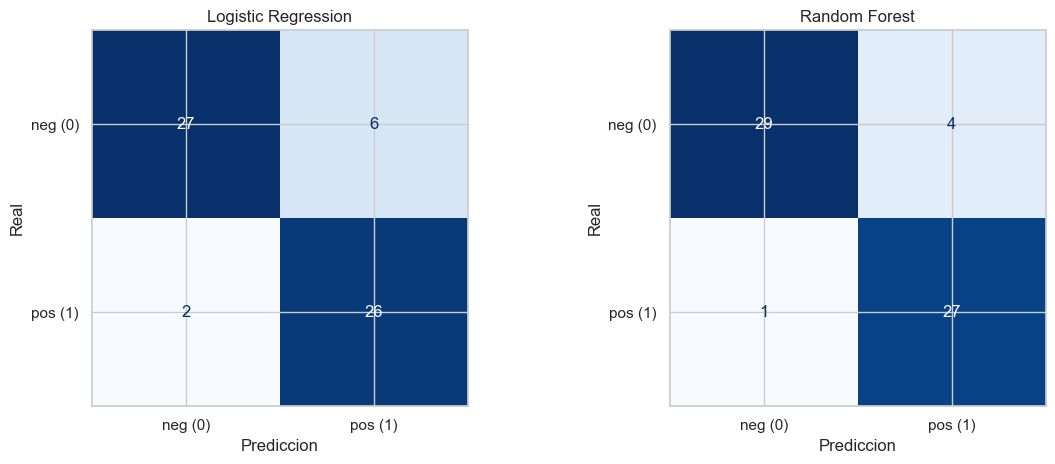

In [25]:
# === 9b. MATRICES DE CONFUSION =============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (nombre, y_pred) in zip(axes, [("Logistic Regression", pred_lr),
                                       ("Random Forest", pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["neg (0)", "pos (1)"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(nombre)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Real")

fig.tight_layout()
fig.savefig(OUT / "05_matrices_confusion.png", dpi=110, bbox_inches="tight")
plt.show()

# Lectura:  [[VN, FP],
#            [FN, VP]]   <- FN (abajo-izquierda) es el error caro en salud.

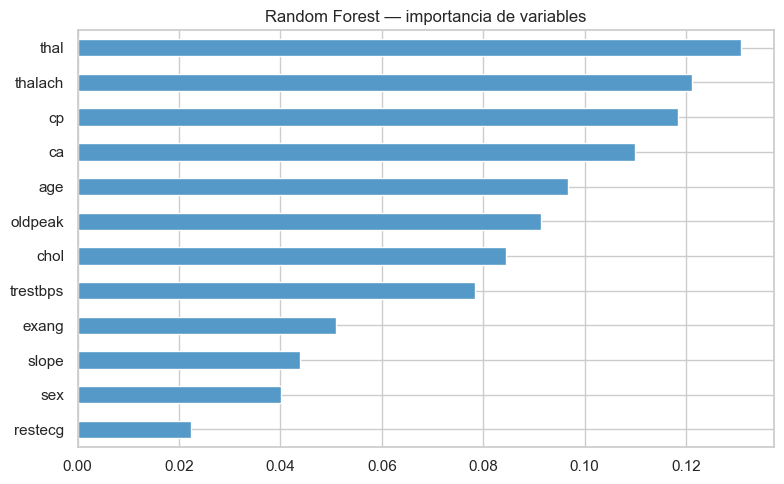

thal        0.1308
thalach     0.1212
cp          0.1184
ca          0.1099
age         0.0968
oldpeak     0.0914
chol        0.0846
trestbps    0.0785
exang       0.0509
slope       0.0438
sex         0.0402
restecg     0.0224

Coeficientes logisticos (+ sube el riesgo / - lo baja):
ca          1.117
thal        0.673
sex         0.669
cp          0.534
exang       0.385
slope       0.362
thalach    -0.359
trestbps    0.313
chol        0.226
fbs        -0.225


In [26]:
# === 9c. QUE VARIABLES PESAN MAS (material directo para tus hallazgos) =====
imp = (pd.Series(rf.feature_importances_, index=X.columns)
         .sort_values(ascending=False).head(12))

fig, ax = plt.subplots(figsize=(8, 5))
imp.sort_values().plot.barh(ax=ax, color="#5499c7")
ax.set_title("Random Forest — importancia de variables")
fig.tight_layout()
fig.savefig(OUT / "06_importancia_variables.png", dpi=110, bbox_inches="tight")
plt.show()

print(imp.round(4).to_string())

# Direccion del efecto (la RF no la da; la logistica si):
coef = (pd.Series(logreg.coef_[0], index=X.columns)
          .sort_values(key=abs, ascending=False).head(10))
print("\nCoeficientes logisticos (+ sube el riesgo / - lo baja):")
print(coef.round(3).to_string())

---
## 10. Hallazgos

> Estructura de cada viñeta: **problema → qué encontré → qué recomendaría.**
> Cada afirmación debe apoyarse en un número concreto del notebook.

- 

- 

- 

**Limitaciones (una línea):** 

In [27]:
# === 10b. RESUMEN NUMERICO PARA LA EXPOSICION ==============================
# Ejecuta esto antes de presentar: son las cifras que vas a citar en voz alta.
print(f"Dataset      : {RUTA_CSV.name}  ({df.shape[0]} filas, {df.shape[1]} columnas)")
print(f"Objetivo     : {TARGET}  | positivos: {y.mean()*100:.1f}%")
print(f"LogReg       : acc {logreg.score(X_test_sc, y_test):.3f} | AUC {roc_auc_score(y_test, proba_lr):.3f}")
print(f"RandomForest : acc {rf.score(X_test, y_test):.3f} | AUC {roc_auc_score(y_test, proba_rf):.3f}")
print(f"Top 3 factores: {', '.join(imp.head(3).index)}")
print(f"Graficas guardadas en: {OUT.resolve()}")

Dataset      : heart_disease.csv  (303 filas, 14 columnas)
Objetivo     : num  | positivos: 45.9%
LogReg       : acc 0.869 | AUC 0.950
RandomForest : acc 0.918 | AUC 0.959
Top 3 factores: thal, thalach, cp
Graficas guardadas en: /Users/cornelio/Desktop/UTP/2026/Concursos/Medata/datathon-meddata/outputs
